In [2]:
from datetime import time
from os import times
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.patches as patches
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import math
from cartopy.mpl.ticker import LongitudeFormatter,LatitudeFormatter

#math的相关函数，import后可以直接使用
from math import radians
from math import sin
from math import cos
from math import asin
from math import sqrt

# np.set_printoptions(threshold=np.inf)#显示所有的数组
from geopy.distance import great_circle
import matplotlib
matplotlib.rcParams['font.family'] = 'Arial'
import seaborn as sns
from scipy import stats
from scipy.ndimage import gaussian_filter
import cartopy.mpl.ticker as cticker
from matplotlib.lines import Line2D
import matplotlib.ticker as mticker

In [3]:
df = pd.read_excel(f'Typhoon_Cluster_3.xlsx')
df['toorilon'] = df['toorilon'].apply(lambda x: x + 360 if x < 0 else x)
id1 = df['Typhoon ID']
idyr = df['year']
oriloclat = df['toorilat']
oriloclon = df['toorilon']

# 分成两个时期的数据
df_period1 = df[(df['year'] >= 1982) & (df['year'] <= 1998)]
df_period2 = df[(df['year'] >= 1999) & (df['year'] <= 2023)]

# 计算两个时期的经纬度平均值
mean_lat_period1 = df_period1['toorilat'].mean()
mean_lon_period1 = df_period1['toorilon'].mean()

mean_lat_period2 = df_period2['toorilat'].mean()
mean_lon_period2 = df_period2['toorilon'].mean()



# 执行t检验，检验两个时期的台风起点纬度的显著性差异
t_stat_lat, p_value_lat = stats.ttest_ind(df_period1['toorilat'], df_period2['toorilat'], equal_var=False)
t_stat_lon, p_value_lon = stats.ttest_ind(df_period1['toorilon'], df_period2['toorilon'], equal_var=False)



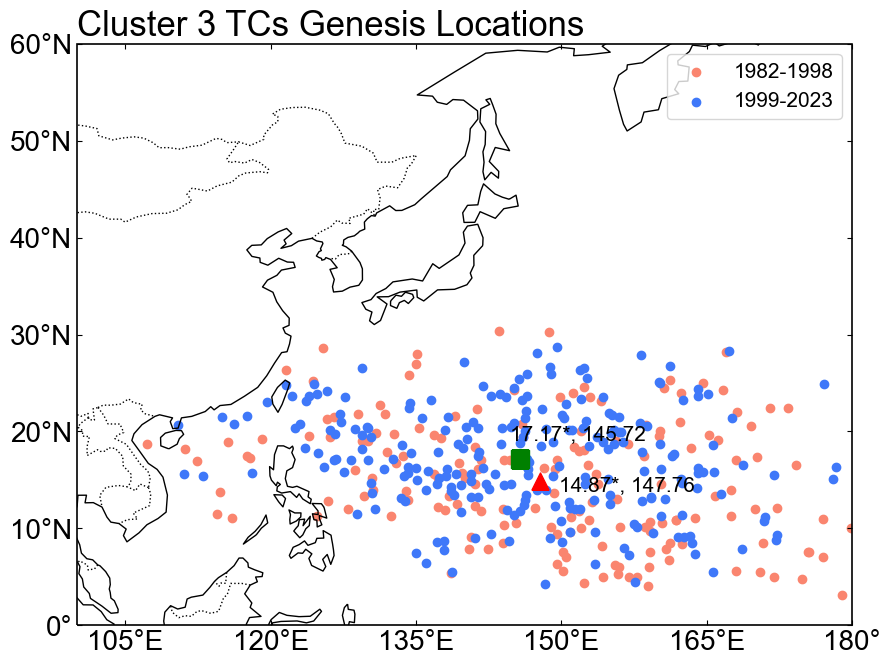

In [4]:
fig = plt.figure(figsize=(10, 8))
ax1= fig.add_subplot(1, 1, 1, projection=ccrs.PlateCarree(central_longitude=180))
ax=ax1
for spine in ax.spines.values():
    spine.set_linewidth(1.2)
ax.set_extent([100, 180, 0, 40])  # 设置地图的经纬度范围
ax.add_feature(cfeature.COASTLINE)
ax.add_feature(cfeature.BORDERS, linestyle=':')
ax.tick_params(left=True, right=True, top=True, bottom=True, labelleft=True, labelbottom=True,direction='in')
ax.set_xticks(np.arange(105, 181, 15), crs=ccrs.PlateCarree())
ax.set_yticks(np.arange(0, 61, 10), crs=ccrs.PlateCarree())
ax.set_xticklabels(np.arange(105, 181, 15),fontsize = 20) # 设置刻度标签
ax.set_yticklabels(np.arange(0, 61, 10),fontsize = 20) # 设置刻度标签
ax.xaxis.set_major_formatter(cticker.LongitudeFormatter())
ax.yaxis.set_major_formatter(cticker.LatitudeFormatter())
added_legend = {'1982-1998': False, '1999-2023': False}
skip_indices = [97, 111,123]
for i in range(len(id1)):
    if i in skip_indices:
        continue  # Skip the plotting for these indices    
    indall = id1[i]
    year = idyr[i]
    lat = oriloclat[i]  # 使用台风起点纬度
    lon = oriloclon[i]  # 使用台风起点经度
    if 1982 <= year <= 1998:
        color = '#fa856f'
        label = '1982-1998'
        if not added_legend[label]:
            ax.scatter(lon, lat, color=color, transform=ccrs.Geodetic(), label=label)
            added_legend[label] = True
        else:
            ax.scatter(lon, lat, color=color, transform=ccrs.Geodetic())    
    elif 1999 <= year <= 2023:
        color =  '#3f78f9'
        label = '1999-2023'
        if not added_legend[label]:
            ax.scatter(lon, lat, color=color, transform=ccrs.Geodetic(), label=label)
            added_legend[label] = True
        else:
            ax.scatter(lon, lat, color=color, transform=ccrs.Geodetic())
ax.legend(loc='upper right', fontsize=15)
mean_lat_period1=14.87
mean_lat_period2=17.17
mean_lon_period1=147.76
mean_lon_period2=145.72
ax.scatter(mean_lon_period1, mean_lat_period1, color='r', marker='^', s=150, label=f'1982-1998 Avg ({mean_lat_period1:.2f}, {mean_lon_period1:.2f})', transform=ccrs.Geodetic())
ax.text(mean_lon_period1 + 2, mean_lat_period1-1, f'{mean_lat_period1:.2f}*, {mean_lon_period1:.2f}', fontsize=15, transform=ccrs.Geodetic())
ax.scatter(mean_lon_period2, mean_lat_period2, color ='green', marker='s', s=150, label=f'1999-2023 Avg ({mean_lat_period2:.2f}, {mean_lon_period2:.2f})', transform=ccrs.Geodetic())
ax.text(mean_lon_period2-1 , mean_lat_period2+2, f'{mean_lat_period2:.2f}*, {mean_lon_period2:.2f}', fontsize=15, transform=ccrs.Geodetic())

# 设置标题和显示图形
ax.set_title('Cluster 3 TCs Genesis Locations', fontsize=25,loc='left')

plt.savefig("pic/02zutu201.pdf",transparent = True)
plt.show()

In [6]:
years = np.arange(1982, 2024)

In [7]:
index=[152.5, 137.5, 160. , 140. , 162.5, 142.5, 150. , 155. , 145. ,
       142.5, 167.5, 137.5, 147.5, 140. , 155. , 142.5, 140. , 137.5,
       150. , 152.5, 147.5, 145. , 140. , 140. , 152.5, 155. , 155. ,
       145. , 132.5, 147.5, 150. , 142.5, 137.5, 150. , 140. , 117.5,
       137.5, 132.5, 117.5, 140. , 110. , 115. ]

In [8]:
tomecur=[1.7939099453090457,
 1.5379027556117502,
 1.6764343172939071,
 1.4267147056509843,
 2.0711415742552224,
 1.3826291240693405,
 2.1402029145516352,
 1.3789691149420602,
 1.514161941795993,
 1.6437862980897897,
 1.7440951421065518,
 1.3653656171427437,
 1.756337608314105,
 1.7574158310933499,
 1.831228943487786,
 1.9389792366738476,
 1.5826751739081693,
 1.358554408436718,
 1.3804501703331484,
 1.4829805487553882,
 1.4962611808040724,
 1.6033931380661663,
 1.431700533283194,
 1.4119012781017781,
 1.5821405561616255,
 1.544820577001158,
 1.3347658844676835,
 1.4600357360792833,
 1.6311453240641929,
 1.749794636688014,
 1.5397778802464868,
 1.499573631780583,
 1.437733682587956,
 1.6213167048210742,
 1.5144458261696698,
 1.6824298870331225,
 1.3644764924813129,
 1.4234313127976026,
 1.431067629752025,
 1.3680763804795113,
 1.4903608646532545,
 1.538733687144302]

In [9]:
x=years

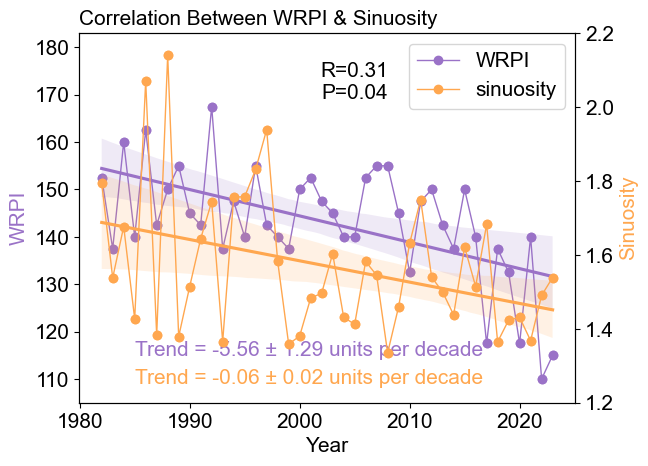

In [10]:
ax1 = fig.add_subplot(2, 2, 2)
ax=ax1
for spine in ax.spines.values():
    spine.set_linewidth(1.2)
y=index
cc1='#9a72c7'
cc2='#ffa74f'
ax1 = sns.regplot(x=x, y=y, ci=95,color=cc1)
lns1=ax1.plot(x,y,'-o', alpha=1, linewidth=1,label='WRPI',color=cc1)
slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)
trend_per_century = slope * 10
std_err_per_century = std_err * 10  # 将标准误差转换为每世纪的不确定性
ax1.text(1985,115,f"Trend = {trend_per_century:.2f} ± {std_err_per_century:.2f} units per decade",fontsize=15,c=cc1)
ax2 = ax1.twinx()  
y=tomecur
ax2 = sns.regplot(x=x, y=y, ci=95,color=cc2)
lns2=ax2.plot(x,y,'-o', alpha=1, linewidth=1,label='sinuosity',c=cc2)
slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)
trend_per_century = slope * 10
std_err_per_century = std_err * 10  # 将标准误差转换为每世纪的不确定性
ax2.text(1985,1.25,f"Trend = {trend_per_century:.2f} ± {std_err_per_century:.2f} units per decade",fontsize=15,c=cc2)
ax1.set_ylim((105, 183))
ax2.set_ylim((1.2, 2.2))
ax1.set_ylabel('WRPI',color=cc1,fontsize='15')
ax2.set_ylabel('Sinuosity',color=cc2,fontsize='15')
ax1.set_xlabel('Year',fontsize='15')
ax1.tick_params(axis='x', labelsize=15)
ax1.tick_params(axis='y', labelsize=15)
ax2.tick_params(axis='x', labelsize=15)
ax2.tick_params(axis='y', labelsize=15)
ax1.set_title("Correlation Between WRPI & Sinuosity",fontsize='15',loc='left')
# ax1.set_title("r=0.31,p=0.04",fontsize='15',loc='right')

ax1.text(2008,177, 'R=0.31\nP=0.04', 
        ha='right', va='top', fontsize=15, color='k')
lns = lns1 + lns2
labs = [l.get_label() for l in lns]
ax1.legend(lns, labs, loc=0, fontsize=15)
plt.savefig("pic/02zutu202.pdf",transparent = True)
plt.show()

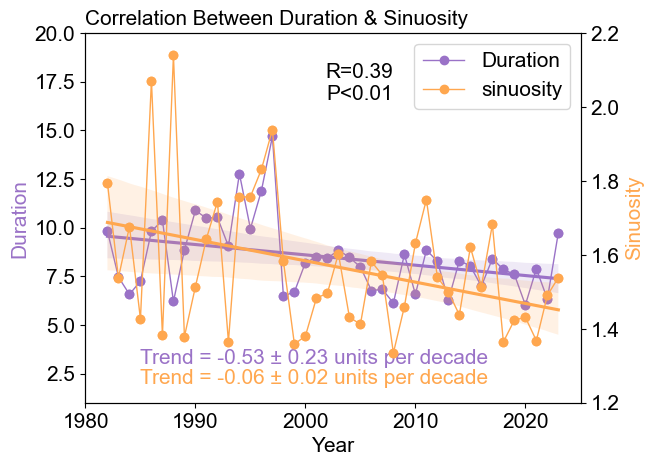

In [11]:
index=[9.825,
 7.458333333333333,
 6.571428571428571,
 7.25,
 9.8125,
 10.375,
 6.204545454545454,
 8.854166666666666,
 10.88888888888889,
 10.48076923076923,
 10.525,
 9.045454545454545,
 12.7734375,
 9.946428571428571,
 11.902777777777779,
 14.6875,
 6.482142857142857,
 6.694444444444445,
 8.201923076923077,
 8.479166666666666,
 8.416666666666666,
 8.854166666666666,
 8.46875,
 7.984375,
 6.767857142857143,
 6.828125,
 6.125,
 8.625,
 6.571428571428571,
 8.84375,
 8.278846153846153,
 6.2727272727272725,
 8.305555555555555,
 8.025,
 6.988636363636363,
 8.402777777777779,
 7.855769230769231,
 7.59375,
 6.027777777777778,
 7.886363636363637,
 6.329545454545454,
 9.75]


ax1 = fig.add_subplot(2, 2, 2)
ax=ax1
for spine in ax.spines.values():
    spine.set_linewidth(1.2)
y=index
cc1='#9a72c7'
cc2='#ffa74f'
ax1 = sns.regplot(x=x, y=y, ci=95,color=cc1)
lns1=ax1.plot(x,y,'-o', alpha=1, linewidth=1,label='Duration',color=cc1)
slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)
trend_per_century = slope * 10
std_err_per_century = std_err * 10  # 将标准误差转换为每世纪的不确定性
ax1.text(1985,3,f"Trend = {trend_per_century:.2f} ± {std_err_per_century:.2f} units per decade",fontsize=15,c=cc1)
ax2 = ax1.twinx()  
y=tomecur
ax2 = sns.regplot(x=x, y=y, ci=95,color=cc2)
lns2=ax2.plot(x,y,'-o', alpha=1, linewidth=1,label='sinuosity',c=cc2)
slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)
trend_per_century = slope * 10
std_err_per_century = std_err * 10  # 将标准误差转换为每世纪的不确定性
ax2.text(1985,1.25,f"Trend = {trend_per_century:.2f} ± {std_err_per_century:.2f} units per decade",fontsize=15,c=cc2)
ax1.set_ylim((1, 20))
ax2.set_ylim((1.2, 2.2))
ax1.set_ylabel('Duration',color=cc1,fontsize='15')
ax2.set_ylabel('Sinuosity',color=cc2,fontsize='15')
ax1.set_xlabel('Year',fontsize='15')
ax1.tick_params(axis='x', labelsize=15)
ax1.tick_params(axis='y', labelsize=15)
ax2.tick_params(axis='x', labelsize=15)
ax2.tick_params(axis='y', labelsize=15)
ax1.set_title("Correlation Between Duration & Sinuosity",fontsize='15',loc='left')
# ax1.set_title("r=0.31,p=0.04",fontsize='15',loc='right')

ax1.text(2008,18.5, 'R=0.39\nP<0.01', 
        ha='right', va='top', fontsize=15, color='k')
lns = lns1 + lns2
labs = [l.get_label() for l in lns]
ax1.legend(lns, labs, loc=0, fontsize=15)
plt.savefig("pic/02zutu203.pdf",transparent = True)
plt.show()

In [12]:
df1 = pd.read_excel(f'Typhoon_Cluster_3.xlsx')
indallc1=np.array(df1['Typhoon ID'])


In [13]:
infile = xr.open_dataset('E:/google/IBTrACS.WP.v04r01.nc')
isotime=infile['iso_time'].values
timec1=isotime[indallc1]
timec1_datetime = np.array([np.datetime64(time.decode('utf-8')) for time in timec1.flatten() if time])

In [14]:
allsst=[]
for i in range(1982,2024):
    print(i)
    data= xr.open_dataset(f'E:/data/daily2.5/geopotential/geo_{i}.nc')
    resst =data['z'][:,0,:,:]/ 9.80665
    res_time = data['valid_time']#需要的时间值
    common_times = np.intersect1d(timec1_datetime, res_time.values)
    sstvalue=resst.sel(valid_time=common_times)
    allsst.append(sstvalue)
    

1982
1983
1984
1985
1986
1987
1988
1989
1990
1991
1992
1993
1994
1995
1996
1997
1998
1999
2000
2001
2002
2003
2004
2005
2006
2007
2008
2009
2010
2011
2012
2013
2014
2015
2016
2017
2018
2019
2020
2021
2022
2023


In [15]:
lonsst=data['longitude']
latsst=data['latitude']

In [18]:
sst_1 = allsst[:17]  # 提取1981到1983年的vws数据
sst_2 = allsst[17:] 
sst_p1 = xr.concat(sst_1, dim='valid_time')
sst_p2 = xr.concat(sst_2, dim='valid_time')
messt_1 = sst_p1.mean(dim='valid_time')
messt_2 = sst_p2.mean(dim='valid_time')

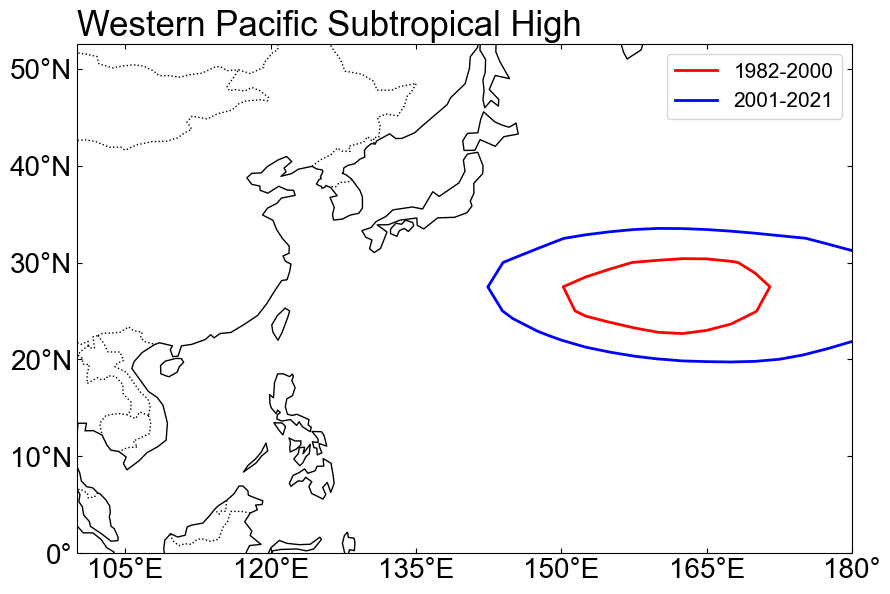

In [19]:
x = years
y1 = index
y2 = tomecur
fig = plt.figure(figsize=(10, 8))
ax0 = fig.add_subplot(1, 1, 1, projection=ccrs.PlateCarree(central_longitude=180))
ax=ax0
ax.set_extent([100, 180, 10, 45])  # 设置地图的经纬度范围
ax.add_feature(cfeature.COASTLINE)
ax.add_feature(cfeature.BORDERS, linestyle=':')
ax.tick_params(left=True, right=True, top=True, bottom=True, labelleft=True, labelbottom=True,direction='in')
ax.set_xticks(np.arange(105, 181, 15), crs=ccrs.PlateCarree())
ax.set_yticks(np.arange(0, 51, 10), crs=ccrs.PlateCarree())
ax.set_xticklabels(np.arange(105, 181, 15),fontsize = 20) # 设置刻度标签
ax.set_yticklabels(np.arange(0, 51, 10),fontsize = 20) # 设置刻度标签
ax.xaxis.set_major_formatter(cticker.LongitudeFormatter())
ax.yaxis.set_major_formatter(cticker.LatitudeFormatter())
# 绘制等值线
ax.contour(lonsst,latsst, messt_1, levels=[5880], colors='r', transform=ccrs.PlateCarree(), linewidths=2)
ax.contour(lonsst,latsst, messt_2, levels=[5880], colors='blue', transform=ccrs.PlateCarree(), linewidths=2)
legend_lines = [
    Line2D([0], [0], color='r', lw=2, label='1982-2000'),
    Line2D([0], [0], color='blue', lw=2, label='2001-2021')
]
ax.legend(handles=legend_lines, loc='upper right', fontsize=15)
ax.set_title('Western Pacific Subtropical High',fontsize=25,loc='left')
# plt.savefig("zutu202.pdf",transparent = True)
plt.show()

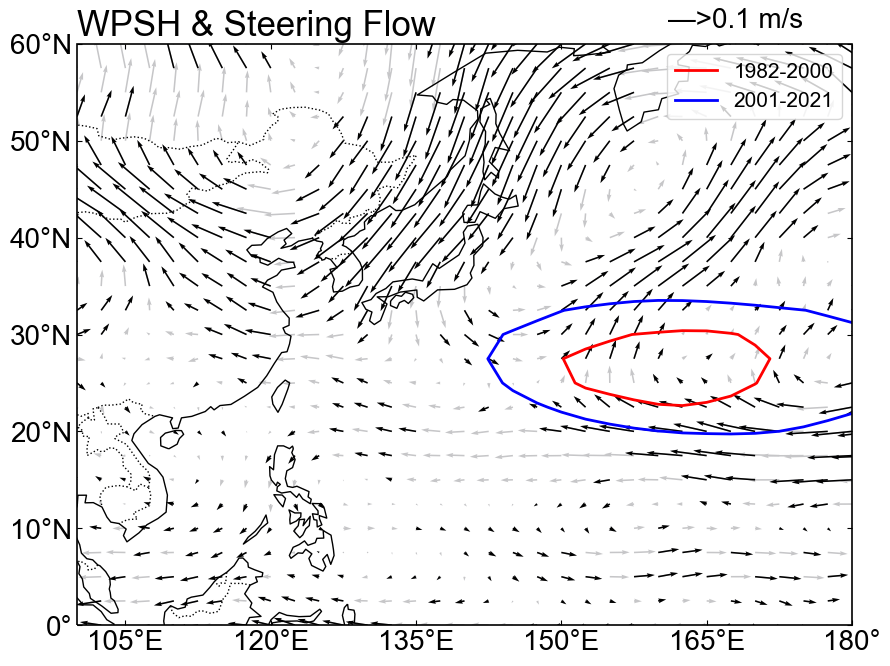

In [20]:
data= xr.open_dataset(f'E:/data/daily2.5/water/water_1982.nc')
lat = data['latitude']
lon = data['longitude']

u_diff= pd.read_excel('string.xlsx')['u_diff'].values.reshape(73, 144)
v_diff= pd.read_excel('string.xlsx')['v_diff'].values.reshape(73, 144)


u_significant=pd.read_excel('stringsig.xlsx')['u_diffsig'].values.reshape(73, 144)
v_significant=pd.read_excel('stringsig.xlsx')['v_diffsig'].values.reshape(73, 144)

u_significant[u_significant==0]=np.nan
v_significant[v_significant==0]=np.nan

fig = plt.figure(figsize=(10, 8))
ax6 = fig.add_subplot(1, 1, 1, projection=ccrs.PlateCarree(central_longitude=180))
for spine in ax6.spines.values():
    spine.set_linewidth(1.2)
ax6.set_extent([100,180, 0,60], crs=ccrs.PlateCarree())
ax6.tick_params(left=True, right=True, top=True, bottom=True, labelleft=True, labelbottom=True,direction='in')
ax6.set_xticks(np.arange(105, 181, 15), crs=ccrs.PlateCarree())
ax6.set_yticks(np.arange(0, 61, 10), crs=ccrs.PlateCarree())
# ax.set_xticks([0,20,40,60]) # 设置刻度
ax6.set_xticklabels(np.arange(105, 181, 15),fontsize = 20) 
ax6.set_yticklabels(np.arange(0, 61, 10),fontsize = 20) # 设置刻度标签
ax6.xaxis.set_major_formatter(cticker.LongitudeFormatter())
ax6.yaxis.set_major_formatter(cticker.LatitudeFormatter())
ax6.add_feature(cfeature.COASTLINE)
ax6.add_feature(cfeature.BORDERS, linestyle=':')
q = ax6.quiver(lon, lat, u_diff, v_diff, width = 0.002, scale = 200000, color='#C6C6C8')
q_significant = ax6.quiver(lon, lat, u_significant, v_significant, width=0.002, scale=200000, color='k')
font = {
        'size'   : 20,
        }

ax6.quiverkey(q, X=0.85, Y=1, U=0.1, label='—>0.1 m/s',angle=0, labelpos='N',fontproperties = font)
ax6.quiverkey(q, X=0.85, Y=1, U=0.1,
              label='→ 0.1 m/s', angle=0, labelpos='N',
              labelsep=0.05, fontproperties={'size': 22})


# ax6.set_title('Steering Flow', loc='left', fontsize=25)
# 绘制等值线
ax6.contour(lonsst,latsst, messt_1, levels=[5880], colors='r', transform=ccrs.PlateCarree(), linewidths=2)
ax6.contour(lonsst,latsst, messt_2, levels=[5880], colors='blue', transform=ccrs.PlateCarree(), linewidths=2)
legend_lines = [
    Line2D([0], [0], color='r', lw=2, label='1982-2000'),
    Line2D([0], [0], color='blue', lw=2, label='2001-2021')
]
ax6.legend(handles=legend_lines, loc='upper right', fontsize=15)
ax6.set_title('WPSH & Steering Flow',fontsize=25,loc='left')


plt.savefig("pic/02zutu204.pdf",transparent = True)
plt.show()

In [17]:
import pandas as pd
import numpy as np


vws= pd.read_excel('vws.xlsx')['vws'].values.reshape(73, 144)
lonvwssig=pd.read_excel('significant_points_vws.xlsx')['significant_points_lon'].values
latvwssig=pd.read_excel('significant_points_vws.xlsx')['significant_points_lat'].values



# Now you can use `tcwv_reshaped` as the 2D array


In [18]:
cmap_value=plt.get_cmap('bwr') 

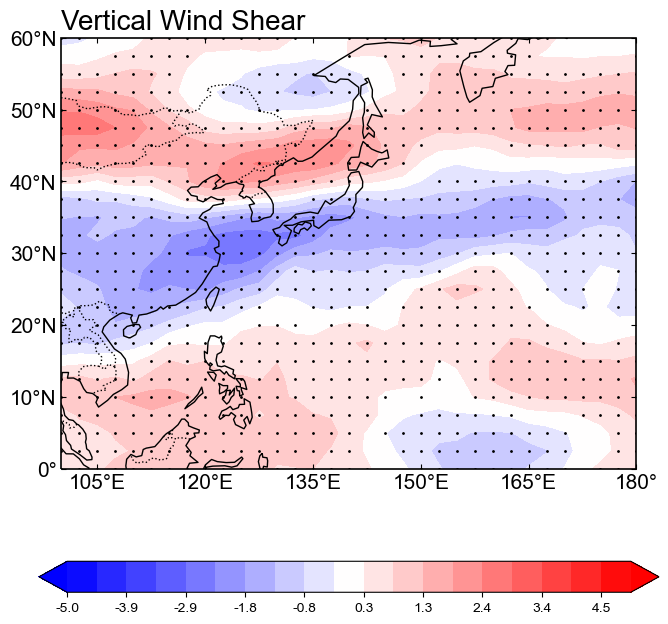

In [19]:
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(1, 1, 1, projection=ccrs.PlateCarree(central_longitude=180))
for spine in ax.spines.values():
    spine.set_linewidth(1.2)
ax.set_extent([100,180, 0,60], crs=ccrs.PlateCarree())

# 绘制网格线
# ax.gridlines(draw_labels=True, dms=True, x_inline=False, y_inline=False)
ax.add_feature(cfeature.COASTLINE)
ax.add_feature(cfeature.BORDERS, linestyle=':')
# cbar2.ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.1f'))
ax.tick_params(left=True, right=True, top=True, bottom=True, labelleft=True, labelbottom=True,direction='in')
ax.set_xticks(np.arange(105, 181, 15), crs=ccrs.PlateCarree())
ax.set_yticks(np.arange(0, 61, 10), crs=ccrs.PlateCarree())
# ax.set_xticks([0,20,40,60]) # 设置刻度
ax.set_xticklabels(np.arange(105, 181, 15),fontsize = 15) 
ax.set_yticklabels(np.arange(0, 61, 10),fontsize = 15) # 设置刻度标签
ax.xaxis.set_major_formatter(cticker.LongitudeFormatter())
ax.yaxis.set_major_formatter(cticker.LatitudeFormatter())

vmin = -5
vmax = 5

# Create contour plot
contour = ax.contourf(lon, lat,  vws, cmap=cmap_value, levels=np.linspace(vmin, vmax, 20), extend='both',transform=ccrs.PlateCarree())


ax.scatter(lonvwssig, latvwssig, color='black', s=1, transform=ccrs.PlateCarree())

cbar = plt.colorbar(contour, ax=ax, orientation='horizontal',shrink=0.8)
# cbar = plt.colorbar(contour, ax=ax, orientation='horizontal', shrink=0.8)

# Ensure the formatting of the colorbar is set to one decimal place
cbar.ax.xaxis.set_major_formatter(mticker.FormatStrFormatter('%.1f'))
ax.set_title('Vertical Wind Shear', loc='left', fontsize=20)
plt.savefig("pic/02zutu205.pdf",transparent = True)
plt.show()

In [20]:
import pandas as pd
import numpy as np



cape= pd.read_excel('cape.xlsx')['cape'].values.reshape(len(lat), len(lon))
loncapesig=pd.read_excel('significant_points_cape.xlsx')['significant_points_lon'].values
latcapesig=pd.read_excel('significant_points_cape.xlsx')['significant_points_lat'].values



# Now you can use `tcwv_reshaped` as the 2D array


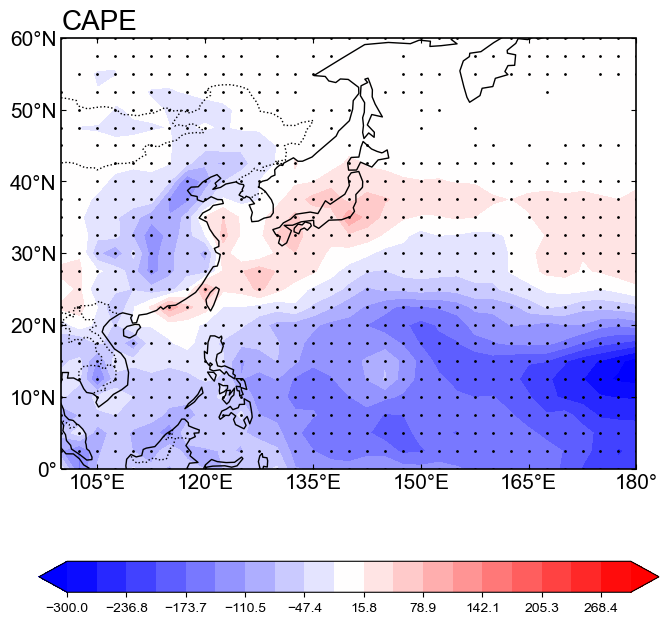

In [23]:
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(1, 1, 1, projection=ccrs.PlateCarree(central_longitude=180))
for spine in ax.spines.values():
    spine.set_linewidth(1.2)
ax.set_extent([100,180, 0,60], crs=ccrs.PlateCarree())

# 绘制网格线
# cbar2.ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.1f'))
ax.tick_params(left=True, right=True, top=True, bottom=True, labelleft=True, labelbottom=True,direction='in')
ax.set_xticks(np.arange(105, 181, 15), crs=ccrs.PlateCarree())
ax.set_yticks(np.arange(0, 61, 10), crs=ccrs.PlateCarree())
# ax.set_xticks([0,20,40,60]) # 设置刻度
ax.set_xticklabels(np.arange(105, 181, 15),fontsize = 15) 
ax.set_yticklabels(np.arange(0, 61, 10),fontsize = 15) # 设置刻度标签
ax.xaxis.set_major_formatter(cticker.LongitudeFormatter())
ax.yaxis.set_major_formatter(cticker.LatitudeFormatter())
ax.add_feature(cfeature.COASTLINE)
ax.add_feature(cfeature.BORDERS, linestyle=':')

vmin = -300
vmax = 300

# Create contour plot
contour = ax.contourf(lon, lat, cape, cmap=cmap_value, levels=np.linspace(-300,300, 20), extend='both',transform=ccrs.PlateCarree())

# 在显著性通过95%的地方打黑点

ax.scatter(loncapesig, latcapesig, color='black', s=1, transform=ccrs.PlateCarree())

cbar = plt.colorbar(contour, ax=ax, orientation='horizontal',shrink=0.8)
ax.set_title('CAPE', loc='left', fontsize=20)
plt.savefig("pic/02zutu206.pdf",transparent = True)
plt.show()